# Ch 6 : Rule Data Mining As A Specification Search - Rule Induction With Variable Complexity

> **L’Eurêka final :** l’induction de règles à complexité variable est puissante parce qu’elle laisse l’algorithme chercher des combinaisons non évidentes, mais elle devient dangereuse dès que la complexité augmente plus vite que la preuve statistique.

Ce notebook transforme le concept en illustration pédagogique orientée **trading algorithmique**, **backtest**, **data mining** et **EBTA**.

L’objectif n’est pas de construire une stratégie gagnante, mais de comprendre pourquoi une règle complexe peut paraître brillante en **in-sample** tout en devenant fragile en **out-of-sample**.


## 1. Idée centrale

L’**induction de règles** est une forme avancée de **data mining** où l’on ne fixe pas seulement quelques paramètres à optimiser.

On laisse plutôt l’algorithme explorer différentes formes de règles :

| Niveau | Exemple | Complexité |
|---:|---|---:|
| 1 | `RSI < 30` | Faible |
| 2 | `RSI < 30 AND prix > moyenne mobile` | Moyenne |
| 3 | `IF volatilité basse AND momentum positif THEN achat` | Élevée |
| 4 | Arbre de décision, réseau de neurones, combinaison non linéaire | Très élevée |

La difficulté est que plus l’espace de recherche est grand, plus il devient facile de trouver une règle qui a simplement **collé au bruit historique**.

> **Conclusion clé :** une règle complexe doit être jugée non pas par sa performance passée maximale, mais par sa capacité à survivre à des données qu’elle n’a jamais vues.


## 2. Traduction EBTA

Dans une logique **EBTA**, une règle de trading n’est pas une opinion visuelle.

C’est une fonction qui transforme des données de marché en positions :

$$
\text{Données de marché} \rightarrow \text{Règle de décision} \rightarrow \text{Position} \rightarrow \text{Rendement de stratégie}
$$

L’induction de règles cherche automatiquement une fonction $f$ :

$$
\text{position}_t = f(X_t)
$$

où $X_t$ représente un ensemble de variables observables : **momentum**, **volatilité**, **retour à la moyenne**, **tendance**, etc.

Le problème est que le nombre de fonctions possibles devient très vite immense.

$$
\text{Risque d'overfitting} \uparrow \quad \text{quand} \quad \text{complexité du modèle} \uparrow
$$


## 3. Exemple intuitif

Imagine que tu donnes à l’ordinateur 20 indicateurs techniques.

Tu ne lui demandes pas seulement :

> “Quelle moyenne mobile est la meilleure ?”

Tu lui demandes plutôt :

> “Combine librement ces indicateurs pour créer la règle qui maximise le backtest.”

C’est exactement là que le danger commence.

Plus l’ordinateur teste de combinaisons, plus il augmente la probabilité de tomber sur une règle qui semble excellente uniquement par hasard.


## 4. Mise en place Python

Nous allons créer un petit laboratoire de recherche de règles.

Le marché simulé contiendra un faible signal caché, mais aussi beaucoup de bruit.

Ensuite, nous comparerons plusieurs niveaux de complexité :

| Modèle | Rôle pédagogique |
|---|---|
| Règle simple | Faible capacité, faible risque d’overfitting |
| Arbre peu profond | Compromis entre structure et robustesse |
| Arbre profond | Forte capacité, risque élevé d’overfitting |

Le but est de visualiser la différence entre **performance d’entraînement**, **performance de test** et **performance de validation**.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)


In [82]:
def generate_market_data(n=1800, seed=7):
    """Génère un marché synthétique avec bruit + faible structure prédictive."""
    rng = np.random.default_rng(seed)
    returns = rng.normal(loc=0.0002, scale=0.01, size=n)

    price = 100 * np.exp(np.cumsum(returns))
    df = pd.DataFrame({"price": price, "return": returns})

    df["momentum_5"] = df["price"].pct_change(5)
    df["momentum_20"] = df["price"].pct_change(20)
    df["volatility_10"] = df["return"].rolling(10).std()
    df["volatility_30"] = df["return"].rolling(30).std()
    df["mean_reversion_10"] = df["price"] / df["price"].rolling(10).mean() - 1
    df["mean_reversion_30"] = df["price"] / df["price"].rolling(30).mean() - 1

    # Signal faible volontairement : le futur dépend un peu du momentum récent et de la volatilité.
    hidden_score = (
        0.8 * df["momentum_5"].fillna(0)
        - 0.4 * df["volatility_10"].fillna(0)
        + rng.normal(0, 0.01, size=n)
    )

    df["target"] = (hidden_score.shift(-1) > 0).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df


df = generate_market_data()
df.head()


,price,return,momentum_5,momentum_20,volatility_10,volatility_30,mean_reversion_10,mean_reversion_30,target
0,88.849975,0.001333,-0.030307,-0.095151,0.009494,0.008362,-0.019542,-0.072482,0
1,87.518301,-0.015101,-0.043245,-0.113245,0.009087,0.008565,-0.028852,-0.082391,0
2,87.118598,-0.004578,-0.023536,-0.120616,0.009018,0.008443,-0.027650,-0.082342,0
3,86.287539,-0.009585,-0.027822,-0.130096,0.008825,0.008478,-0.031617,-0.086671,0
4,85.609548,-0.007888,-0.035185,-0.129037,0.008323,0.008467,-0.032870,-0.089475,0


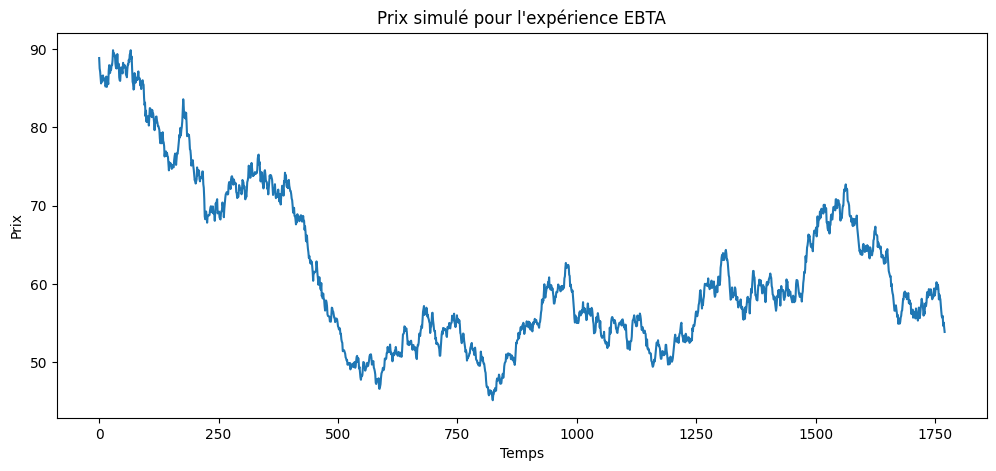

In [83]:
plt.figure(figsize=(12, 5))
plt.plot(df["price"].values)
plt.title("Prix simulé pour l'expérience EBTA")
plt.xlabel("Temps")
plt.ylabel("Prix")
plt.show()


## 5. Séparation entraînement, test et validation

Pour l’induction de règles, une simple séparation **in-sample / out-of-sample** ne suffit pas toujours.

On utilise idéalement trois zones :

| Zone | Utilisation | Danger si mal utilisée |
|---|---|---|
| Entraînement | Le modèle apprend la règle | Normal |
| Test | On choisit la complexité optimale | Peut devenir indirectement contaminé |
| Validation | Vérification finale sans biais | Ne doit jamais guider la sélection |

> **Règle EBTA :** la validation finale doit rester intouchable jusqu’à la toute fin.


In [84]:
features = [
    "momentum_5",
    "momentum_20",
    "volatility_10",
    "volatility_30",
    "mean_reversion_10",
    "mean_reversion_30",
]

y = df["target"]
X = df[features]

n = len(df)
train_end = int(n * 0.50)
test_end = int(n * 0.75)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_test, y_test = X.iloc[train_end:test_end], y.iloc[train_end:test_end]
X_val, y_val = X.iloc[test_end:], y.iloc[test_end:]

len(X_train), len(X_test), len(X_val)


(885, 443, 443)

## 6. Induction avec complexité variable

Nous allons faire varier la profondeur maximale d’un **arbre de décision**.

La profondeur représente ici la complexité de la règle :

$$
\text{complexité} \approx \text{nombre de conditions successives dans la règle}
$$

Un arbre peu profond peut apprendre une relation simple.

Un arbre très profond peut mémoriser des détails accidentels du passé.


In [119]:
results = []
models = {}

for depth in range(1, 30):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "validation_accuracy": val_acc,
    })
    models[depth] = model

results_df = pd.DataFrame(results)
results_df


,max_depth,train_accuracy,test_accuracy,validation_accuracy
0,1,0.776271,0.749436,0.760722
1,2,0.778531,0.731377,0.751693
2,3,0.800000,0.715576,0.724605
3,4,0.802260,0.699774,0.722348
4,5,0.828249,0.717833,0.695260
5,6,0.854237,0.717833,0.686230
6,7,0.875706,0.706546,0.717833
7,8,0.891525,0.688488,0.656885
8,9,0.908475,0.697517,0.643341
9,10,0.929944,0.693002,0.656885


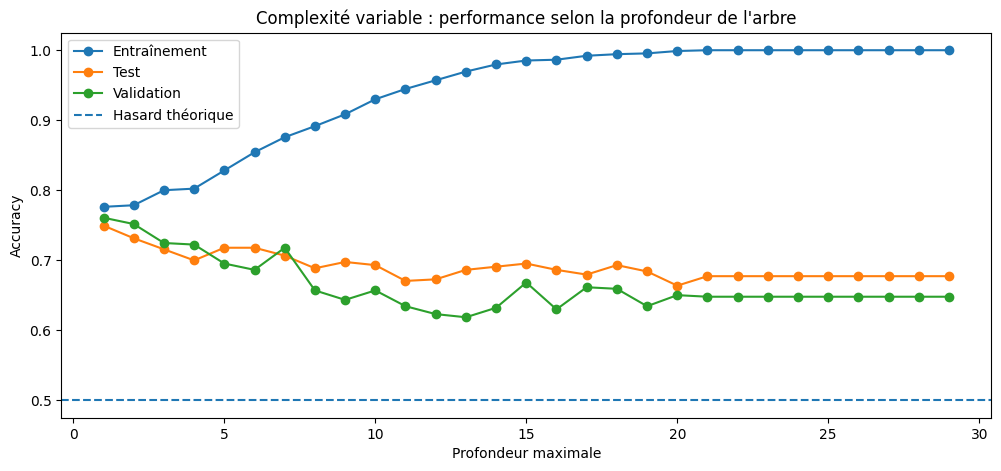

In [120]:
plt.figure(figsize=(12, 5))
plt.plot(results_df["max_depth"], results_df["train_accuracy"], marker="o", label="Entraînement")
plt.plot(results_df["max_depth"], results_df["test_accuracy"], marker="o", label="Test")
plt.plot(results_df["max_depth"], results_df["validation_accuracy"], marker="o", label="Validation")
plt.axhline(0.50, linestyle="--", label="Hasard théorique")
plt.title("Complexité variable : performance selon la profondeur de l'arbre")
plt.xlabel("Profondeur maximale")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## 7. Lecture des résultats

Ce graphique illustre le comportement typique d’une recherche à complexité variable.

La performance d’entraînement monte souvent avec la complexité :

$$
\text{performance in-sample} \uparrow
$$

Mais la performance de validation peut stagner ou baisser :

$$
\text{performance validation} \not\uparrow
$$

C’est le symptôme classique du **sur-ajustement**.

> **Point crucial :** le modèle le plus complexe n’est pas forcément le meilleur modèle. C’est souvent seulement celui qui a le mieux mémorisé le passé.


In [121]:
best_depth_by_test = results_df.loc[results_df["test_accuracy"].idxmax(), "max_depth"]
best_row = results_df.loc[results_df["test_accuracy"].idxmax()]

print(f"Meilleure profondeur selon le test : {int(best_depth_by_test)}")
print(best_row)


Meilleure profondeur selon le test : 1
max_depth              1.000000
train_accuracy         0.776271
test_accuracy          0.749436
validation_accuracy    0.760722
Name: 0, dtype: float64


## 8. Transformation en backtest simplifié

L’accuracy seule ne suffit pas.

En trading, ce qui compte est le rendement obtenu par les positions générées.

Nous allons convertir la prédiction du modèle en position :

$$
\text{position}_t =
\begin{cases}
+1 & \text{si le modèle prédit une hausse} \\
-1 & \text{si le modèle prédit une baisse}
\end{cases}
$$

Puis :

$$
\text{rendement stratégie}_t = \text{position}_{t-1} \times \text{rendement marché}_t
$$


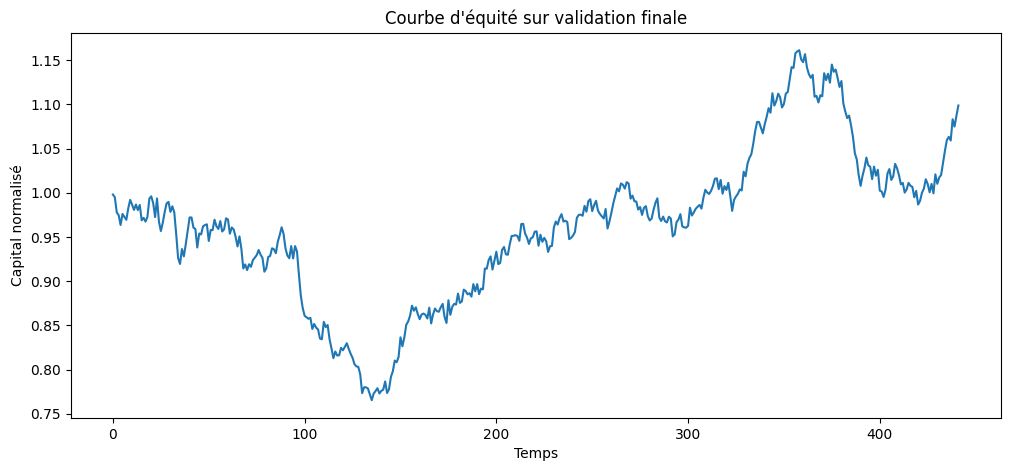

Rendement total validation : 9.88 %
Rendement moyen journalier : 0.0269 %
Volatilité journalière : 1.0571 %


In [122]:
def backtest_model(model, X_part, returns_part):
    predictions = model.predict(X_part)
    positions = np.where(predictions == 1, 1, -1)

    strategy_returns = pd.Series(positions, index=X_part.index).shift(1) * returns_part
    strategy_returns = strategy_returns.dropna()

    equity = (1 + strategy_returns).cumprod()
    return strategy_returns, equity

# Modèle choisi via le test
selected_model = models[int(best_depth_by_test)]

returns_val = df.loc[X_val.index, "return"]
strategy_returns_val, equity_val = backtest_model(selected_model, X_val, returns_val)

plt.figure(figsize=(12, 5))
plt.plot(equity_val.values)
plt.title("Courbe d'équité sur validation finale")
plt.xlabel("Temps")
plt.ylabel("Capital normalisé")
plt.show()

print("Rendement total validation :", round((equity_val.iloc[-1] - 1) * 100, 2), "%")
print("Rendement moyen journalier :", round(strategy_returns_val.mean() * 100, 4), "%")
print("Volatilité journalière :", round(strategy_returns_val.std() * 100, 4), "%")


## 9. Comparaison avec un modèle trop complexe

Nous allons maintenant comparer le modèle sélectionné avec un arbre volontairement très profond.

L’idée est simple :

- le modèle complexe peut dominer sur l’entraînement ;
- mais il peut échouer sur la validation ;
- c’est exactement le danger de l’induction sans protocole robuste.


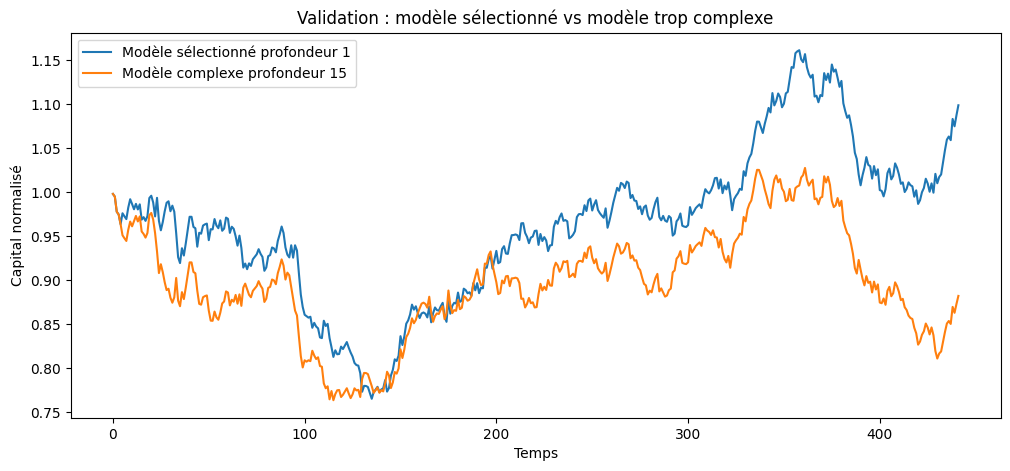

In [131]:
complex_depth = 15
complex_model = models[complex_depth]

_, equity_selected = backtest_model(selected_model, X_val, returns_val)
_, equity_complex = backtest_model(complex_model, X_val, returns_val)

plt.figure(figsize=(12, 5))
plt.plot(equity_selected.values, label=f"Modèle sélectionné profondeur {int(best_depth_by_test)}")
plt.plot(equity_complex.values, label=f"Modèle complexe profondeur {complex_depth}")
plt.title("Validation : modèle sélectionné vs modèle trop complexe")
plt.xlabel("Temps")
plt.ylabel("Capital normalisé")
plt.legend()
plt.show()


## 10. Le piège du data mining

L’induction de règles à complexité variable est une arme à double tranchant.

Elle peut découvrir des relations invisibles à l’œil humain, mais elle peut aussi fabriquer une illusion statistique.

Le piège se résume ainsi :

$$
\text{beaucoup de règles testées} + \text{bruit de marché} = \text{fausses découvertes probables}
$$

En EBTA, la solution n’est pas de refuser les modèles complexes.

La solution est de les entourer d’un protocole rigoureux :

- séparation stricte des données ;
- contrôle de la complexité ;
- validation finale non touchée ;
- tests de robustesse ;
- prise en compte des coûts de transaction ;
- méfiance envers les performances trop parfaites.


## 11. Checklist EBTA pour l’induction de règles

| Question | Réponse attendue avant trading réel |
|---|---|
| Le modèle a-t-il été entraîné uniquement sur l’échantillon d’entraînement ? | Oui |
| Le test a-t-il servi uniquement à choisir la complexité ? | Oui |
| La validation est-elle restée totalement intouchée ? | Oui |
| La performance validation reste-t-elle positive après coûts ? | Oui |
| La règle est-elle stable sur plusieurs périodes ? | Oui |
| La performance disparaît-elle quand on change légèrement les paramètres ? | Non |
| Le nombre de règles testées est-il pris en compte ? | Oui |

> **L’Eurêka final :** l’induction devient scientifique seulement quand la recherche automatique est séparée de la preuve finale.


## 12. Résumé opérationnel

L’induction de règles à complexité variable correspond à la forme la plus ambitieuse du **data mining** appliqué au trading.

Elle ne se contente pas de régler une stratégie existante.

Elle tente de découvrir automatiquement la structure de la stratégie elle-même.

Mais cette puissance augmente aussi le risque de **data mining bias**.

La bonne attitude EBTA est donc :

> Chercher librement, mais prouver strictement.

Autrement dit :

$$
\text{créativité algorithmique} + \text{discipline statistique} = \text{recherche robuste}
$$


## 13. Exercice pratique

Modifie les éléments suivants dans le code :

- la graine aléatoire `seed` ;
- le nombre d’observations `n` ;
- la profondeur maximale de l’arbre ;
- les variables utilisées dans `features` ;
- la séparation entre entraînement, test et validation.

Observe ensuite :

1. si la meilleure complexité reste stable ;
2. si la validation confirme le test ;
3. si le modèle complexe bat réellement le modèle simple ;
4. si la courbe d’équité reste robuste.

> **But de l’exercice :** développer le réflexe de ne jamais croire une règle simplement parce qu’elle a gagné sur le passé.


## Annexe — Source originale collée

Le texte ci-dessous est la source fournie par l’utilisateur pour construire ce notebook.



### **CH 6 : RULE DATA MINING AS A SPECIFICATION SEARCH - RULE INDUCTION WITH VARIABLE COMPLEXITY**

Voici l’analyse technique de l’induction de règles à complexité variable, définie par David Aronson comme la forme de minage de données la plus vaste et la plus ambitieuse de l'analyse technique objective.

#### **Idées clés :**
*   **Complexité indéfinie :** Contrairement à l'optimisation ou à la recherche de règles simples, l'induction explore des configurations dont la complexité (nombre de paramètres et d'opérateurs) n'est pas fixée au départ.
*   **Synthèse autonome :** Cette méthode utilise l'apprentissage automatique (machine learning) pour combiner des règles simples entre elles afin de créer des modèles plus puissants.
*   **Évolution progressive :** Le processus commence par tester des règles isolées, puis des paires, en augmentant la complexité tant que la performance s'améliore.
*   **Recherche de l'optimum :** L'objectif final est d'identifier le niveau de complexité idéal qui maximise le pouvoir prédictif sans tomber dans le sur-ajustement (overfitting).

#### **Référence :**
*Rule Induction with Variable Complexity*, Chapitre 6, page 267.

#### **Citation Directe :**
« The broadest and most ambitious form of data mining is rule induction. Here the search considers rules of undefined complexity. As the search proceeds, rules of ever-greater complexity are considered. » (Page 267).

---

#### **Vision Macro :**
L'enjeu est de répondre à la complexité des marchés financiers par des solutions d'une complexité équivalente. Aronson invoque la **Loi de la Variété Requise d'Ashby**, qui stipule qu'un système de contrôle (la règle de trading) doit être aussi complexe que le système qu'il tente de prédire (le marché). L'induction de règles permet de découvrir des synergies informationnelles entre des indicateurs qui, pris isolément, pourraient sembler inutiles, mais qui deviennent prédictifs une fois combinés de manière non linéaire.

---

#### **Vision Micro :**
Le mécanisme de l'induction repose sur une boucle d'apprentissage automatisée :

1.  **Point de départ :** L'algorithme teste d'abord des règles simples (ex: un seul indicateur).
2.  **Combinaison Logique/Mathématique :** Il utilise des opérateurs logiques (AND, OR, IF-THEN) ou des fonctions mathématiques pour fusionner plusieurs signaux.
3.  **Algorithmes Avancés :** Pour naviguer dans cet espace de recherche quasi infini, l'induction utilise des outils tels que les **réseaux de neurones**, les **algorithmes génétiques**, les machines à vecteurs de support (SVM) ou les arbres de décision.
4.  **Détection du "Pic" :** La complexité augmente graduellement. La performance est surveillée sur un échantillon de test. Dès que la performance sur ces données commence à décliner alors qu'elle continue de monter sur les données d'entraînement, l'algorithme a atteint la limite de l'overfitting et doit s'arrêter.

---

#### **Résumé Simplifié :**
L'induction, c'est laisser l'ordinateur jouer aux LEGO avec vos indicateurs. Au lieu de lui dire "teste ce croisement de moyennes mobiles", vous lui dites "voici 50 indicateurs, combine-les comme tu veux pour trouver la formule magique". L'ordinateur va empiler les couches de calcul jusqu'à trouver une stratégie très sophistiquée qui colle à la réalité du marché.

---

#### **Exemples du livre pour mieux comprendre :**
*   **Synergie des indicateurs :** Aronson mentionne qu'une règle complexe peut être profitable même si les règles simples qui la composent ne le sont pas individuellement.
*   **L'analogie de la recette :** Si l'optimisation est le réglage de la cuisson, l'induction est l'invention complète d'une nouvelle recette en mélangeant des ingrédients de manière inédite.
*   **Réseaux de neurones :** Le livre cite leur capacité à combiner des signaux d'achat/vente de moyennes mobiles simples en modèles non linéaires affichant une bonne capacité prédictive.

---

#### **Actions Concrètes :**
*   **Utiliser trois jeux de données :** Pour cette méthode, vous devez impérativement séparer vos données en trois : **Entraînement** (pour créer la règle), **Test** (pour trouver la complexité optimale) et **Validation** (pour vérifier le profit réel sans biais).
*   **Surveiller la "Malédiction de la Dimensionnalité" :** Plus vous ajoutez d'indicateurs (dimensions), plus vous avez besoin d'un nombre exponentiel de données historiques pour que le modèle reste valide.
*   **Automatiser la recherche :** Ne tentez pas de combiner manuellement des règles complexes ; l'esprit humain est incapable de gérer les relations non linéaires et le bruit aussi efficacement que les algorithmes de data mining.

---

#### **À retenir absolument :**
*   **Induction** = Complexité variable et apprentissage automatique.
*   Elle permet de découvrir des **relations cachées** entre indicateurs.
*   Le risque de **sur-ajustement (overfitting)** est maximal avec cette méthode.
*   C'est la forme de recherche la plus **scientifiquement avancée** de l'EBTA.
*   Nécessite impérativement un **échantillon de Validation** non touché pour confirmer le talent.

J'ai terminé l'analyse de l'induction de règles à complexité variable selon le protocole EBTA.
```
